# 🎓 Student Learning Engagement Analyzer
## End-to-End ML Pipeline — Google Colab Notebook

This notebook covers the **complete project pipeline**:
1. Environment setup & secret injection
2. Install dependencies
3. Upload project zip → unpack
4. Data loading & understanding (N1)
5. Engagement & target design (N2)
6. Temporal engagement analysis (N3)
7. Model training + **MLflow / DagsHub** tracking (N4)
8. Evaluation & explainability
9. Recommendation engine
10. End-to-end prediction pipeline
11. Batch predictions on test set
12. Save all outputs & **download as ZIP**

## 🔐 Step 1 — Set Environment Variables (Colab Secrets)

In [1]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ Set to False to use local MLflow

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 📦 Step 2 — Install Dependencies

In [2]:
%%capture
!pip install pandas numpy scikit-learn joblib pyyaml mlflow dagshub pymongo

## 📁 Step 3 — Upload & Unpack Project Code

Upload **`project_code.zip`** when the file picker appears below.

In [3]:
from google.colab import files
import zipfile, os

print("📂 Please upload project_code.zip ...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {zip_name}")

os.makedirs("/content/project", exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall("/content/project")
print("✅ Extracted to /content/project")

for item in sorted(os.listdir("/content/project")):
    print("   ", item)

📂 Please upload project_code.zip ...


Saving project_code.zip to project_code.zip

✅ Uploaded: project_code.zip
✅ Extracted to /content/project
    .gitignore
    .python-version
    config
    core
    dataset
    main.py
    models
    requirements.txt
    requirements_new.txt
    streamlit_app.py
    test
    utils


## 🗂️ Step 4 — Configure Paths & Python Path

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/project")
DATASET_PATH = PROJECT_ROOT / "dataset" / "artefacts"
MODEL_PATH   = PROJECT_ROOT / "models"  / "artefacts"
CONFIG_PATH  = PROJECT_ROOT / "config"
OUTPUT_DIR   = Path("/content/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_PATH :", DATASET_PATH)
print("MODEL_PATH   :", MODEL_PATH)
print("CONFIG_PATH  :", CONFIG_PATH)
print("OUTPUT_DIR   :", OUTPUT_DIR)

for p in [DATASET_PATH, MODEL_PATH, CONFIG_PATH]:
    found = list(p.iterdir()) if p.exists() else []
    print(f"\n{p.name}/ ({len(found)} files):")
    for f in found:
        print("    ", f.name)

PROJECT_ROOT : /content/project
DATASET_PATH : /content/project/dataset/artefacts
MODEL_PATH   : /content/project/models/artefacts
CONFIG_PATH  : /content/project/config
OUTPUT_DIR   : /content/outputs

artefacts/ (3 files):
     student_master_v2.csv
     student_master_v1.csv
     student_master_v3_temporal.csv

artefacts/ (1 files):
     finalized_model.joblib

config/ (1 files):
     config.yaml


## 📊 Step 5 — Data Understanding & Memory-Safe Loading (N1)

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df_v1 = pd.read_csv(DATASET_PATH / "student_master_v1.csv")
df_v2 = pd.read_csv(DATASET_PATH / "student_master_v2.csv")
df_v3 = pd.read_csv(DATASET_PATH / "student_master_v3_temporal.csv")

print(f"v1 shape : {df_v1.shape}")
print(f"v2 shape : {df_v2.shape}")
print(f"v3 shape : {df_v3.shape}")

v1 shape : (32593, 16)
v2 shape : (32593, 19)
v3 shape : (32593, 23)


In [6]:
print("=== Dataset V1 — First 5 rows ===")
display(df_v1.head())

print("\n=== Data Types ===")
display(df_v1.dtypes.to_frame("dtype"))

print("\n=== Nulls per column ===")
display(df_v1.isnull().sum().to_frame("null_count"))

=== Dataset V1 — First 5 rows ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_click,avg_clicks_per_day,max_clicks_day,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,4.765306,76.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,3.337209,23.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,3.697368,23.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,3.254902,22.0,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,2.937500,22.0,70.0



=== Data Types ===


,dtype
code_module,object
code_presentation,object
id_student,int64
gender,object
region,object
highest_education,object
imd_band,object
age_band,object
num_of_prev_attempts,int64
studied_credits,int64



=== Nulls per column ===


,null_count
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [7]:
print("=== V1 Descriptive Statistics ===")
display(df_v1.describe().T)

=== V1 Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.000000,590310.000000,644453.000000,2.716795e+06
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.000000,0.000000,0.000000,6.000000e+00
studied_credits,32593.0,79.758691,41.071900,30.0,60.000000,60.000000,120.000000,6.550000e+02
total_click,29741.0,1620.864665,2050.309532,1.0,324.000000,903.000000,2171.000000,2.861500e+04
avg_clicks_per_day,29741.0,3.296364,1.187155,1.0,2.408696,3.128415,4.007533,1.942754e+01
max_clicks_day,29741.0,58.197909,105.572177,1.0,18.000000,38.000000,78.000000,6.977000e+03
active_days,29741.0,69.603208,58.102993,1.0,22.000000,55.000000,104.000000,2.860000e+02


In [8]:
new_cols = set(df_v2.columns) - set(df_v1.columns)
print(f"New columns in v2 vs v1: {new_cols}")
display(df_v2.head(3))

New columns in v2 vs v1: {'engagement_level', 'no_engagement_flag', 'success'}


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_click,avg_clicks_per_day,max_clicks_day,active_days,success,engagement_level,no_engagement_flag
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,4.765306,76.0,40.0,1,Medium,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,3.337209,23.0,80.0,1,High,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,3.697368,23.0,12.0,0,Low,0


In [9]:
print("=== Dataset V3 (Temporal) — Info ===")
df_v3.info()
print("\n=== First 5 rows ===")
display(df_v3.head())

=== Dataset V3 (Temporal) — Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  total_click           32593 non-null  float64
 13  avg_clicks_per_day    32593 non-null  float64
 14  max_clicks_day        32593 non-n

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,avg_clicks_per_day,max_clicks_day,active_days,success,engagement_level,no_engagement_flag,first_activity_day,pre_course_engaged,early_click,early_active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,4.765306,76.0,40.0,1,Medium,0,-5.0,1.0,203.0,5.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,3.337209,23.0,80.0,1,High,0,-10.0,1.0,241.0,7.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,3.697368,23.0,12.0,0,Low,0,-10.0,1.0,179.0,6.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,3.254902,22.0,123.0,1,High,0,-10.0,1.0,180.0,8.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,2.937500,22.0,70.0,1,Medium,0,-10.0,1.0,177.0,9.0


## 🎯 Step 6 — Engagement Understanding & Target Design (N2)

In [10]:
df = df_v2.copy()
print("total_click stats:")
print(df["total_click"].describe())

total_click stats:
count    32593.000000
mean      1479.033412
std       2011.390856
min          0.000000
25%        205.000000
50%        758.000000
75%       1990.000000
max      28615.000000
Name: total_click, dtype: float64


In [11]:
df["click_bin"] = pd.qcut(df["total_click"], q=5, labels=False, duplicates="drop")
click_success = (
    df.groupby("click_bin")["final_result"]
    .apply(lambda x: (x == "Pass").mean())
    .reset_index()
)
click_success.columns = ["click_bin", "pass_rate"]
print("Pass rate by click quintile:")
display(click_success)

Pass rate by click quintile:


,click_bin,pass_rate
0,0,0.017450
1,1,0.266718
2,2,0.446472
3,3,0.563210
4,4,0.603038


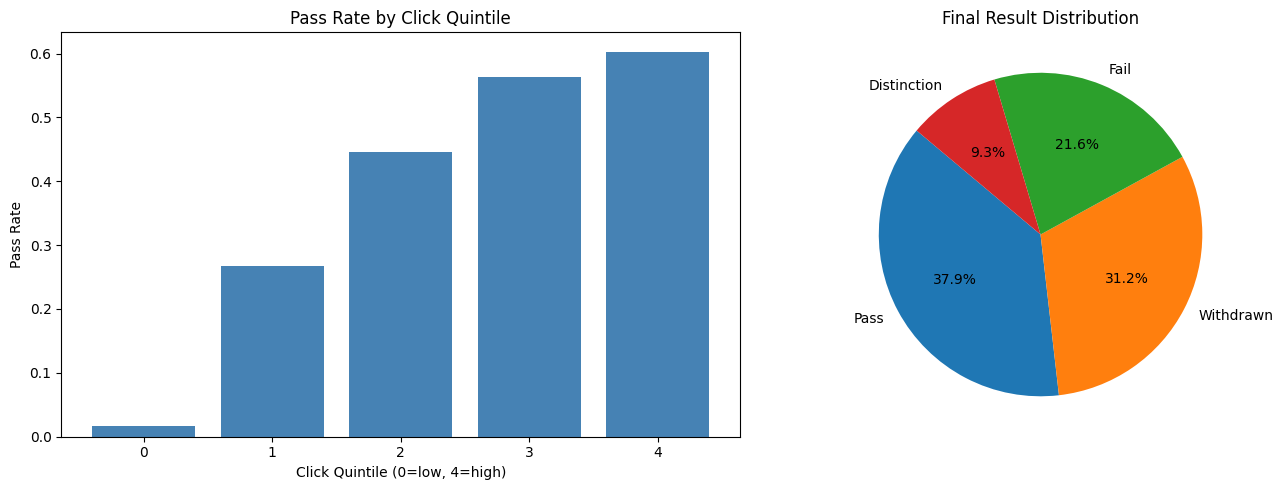

✅ Saved: 01_engagement_overview.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(click_success["click_bin"], click_success["pass_rate"], color="steelblue")
axes[0].set_xlabel("Click Quintile (0=low, 4=high)")
axes[0].set_ylabel("Pass Rate")
axes[0].set_title("Pass Rate by Click Quintile")

outcome_counts = df["final_result"].value_counts()
axes[1].pie(outcome_counts, labels=outcome_counts.index, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Final Result Distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_engagement_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 01_engagement_overview.png")

In [13]:
df["at_risk"] = df["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

print("Target distribution:")
print(df["at_risk"].value_counts())
print(f"At-risk rate: {df['at_risk'].mean():.2%}")

Target distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64
At-risk rate: 52.80%


## ⏱️ Step 7 — Temporal Engagement & Early Signals (N3)

In [14]:
df_t = df_v3.copy()
print("Temporal dataset columns:")
print(df_t.columns.tolist())
print(f"\nShape: {df_t.shape}")

Temporal dataset columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_click', 'avg_clicks_per_day', 'max_clicks_day', 'active_days', 'success', 'engagement_level', 'no_engagement_flag', 'first_activity_day', 'pre_course_engaged', 'early_click', 'early_active_days']

Shape: (32593, 23)


In [15]:
feature_cols = [
    "total_click",
    "early_click",
    "early_active_days",
    "first_activity_day",
    "pre_course_engaged",
]

available = [c for c in feature_cols if c in df_t.columns]

if "at_risk" not in df_t.columns and "final_result" in df_t.columns:
    df_t["at_risk"] = df_t["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

corr = df_t[available + ["at_risk"]].corr()["at_risk"].sort_values()
print("Correlation with at_risk target:")
display(corr.to_frame("correlation"))

Correlation with at_risk target:


,correlation
total_click,-0.411574
early_active_days,-0.316654
pre_course_engaged,-0.233879
early_click,-0.231093
first_activity_day,0.073112
at_risk,1.000000


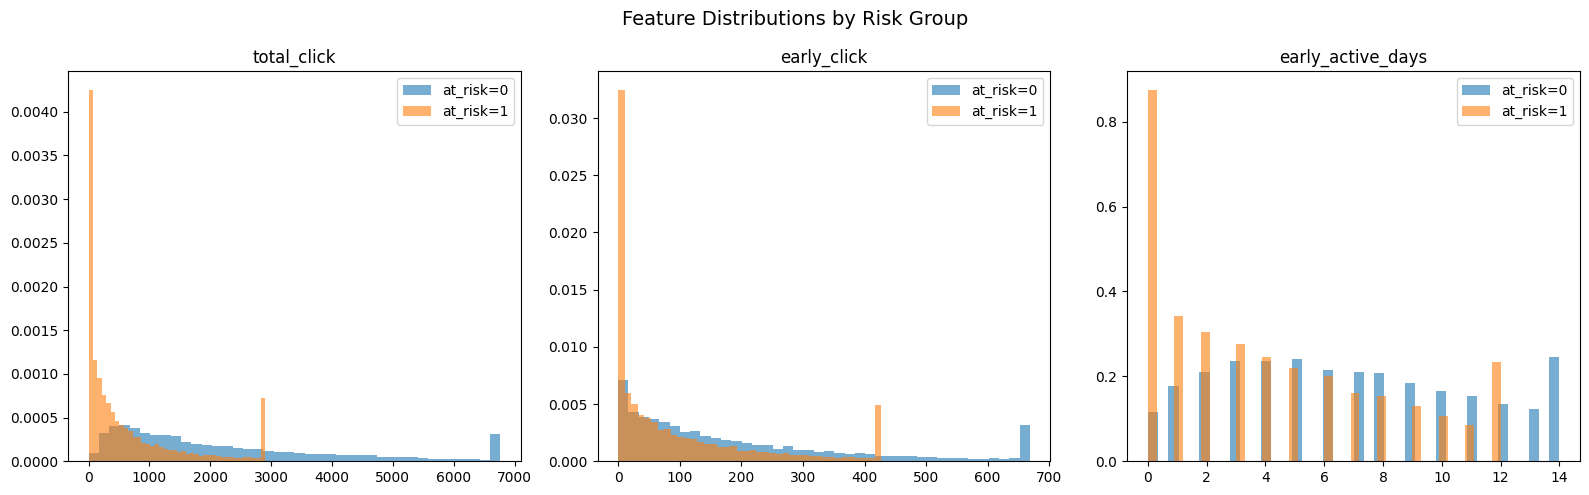

✅ Saved: 02_temporal_signals.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["total_click", "early_click", "early_active_days"]):
    if col not in df_t.columns:
        continue
    for risk, grp in df_t.groupby("at_risk"):
        ax.hist(
            grp[col].dropna().clip(upper=grp[col].quantile(0.95)),
            bins=40, alpha=0.6, label=f"at_risk={risk}", density=True
        )
    ax.set_title(col)
    ax.legend()

plt.suptitle("Feature Distributions by Risk Group", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_temporal_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 02_temporal_signals.png")

## 🤖 Step 8 — Model Training with MLflow / DagsHub Tracking (N4)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, roc_curve
)
import joblib

feature_cols = [
    "total_click",
    "early_click",
    "early_active_days",
    "first_activity_day",
    "pre_course_engaged",
]

if "at_risk" not in df_t.columns:
    df_t["at_risk"] = df_t["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

X = df_t[feature_cols].copy()
y = df_t["at_risk"].copy()

# Handle students who never started (NaN first_activity_day → 999)
X["first_activity_day"] = X["first_activity_day"].fillna(999)
X = X.fillna(0)

print(f"X shape : {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape : (32593, 5)
y distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (26074, 5)  |  Test: (6519, 5)


In [19]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

if USE_DAGSHUB:
    import dagshub
    tracking_uri = os.environ["MLFLOW_TRACKING_URI"]
    # Parse owner/repo from DagsHub URI: https://dagshub.com/<owner>/<repo>.mlflow
    parts = tracking_uri.replace("https://dagshub.com/", "").replace(".mlflow", "").split("/")
    repo_owner, repo_name = parts[0], parts[1]
    dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)

mlflow.set_experiment("student-engagement-risk")
print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=973c6ac9-9cb1-4b50-a101-ce1c757cf093&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=899b860e673c00e23f210ab32e377250601df60ae587d05e9bfd322317497958




Accessing as prithusarkar90

Initialized MLflow to track repo "prithusarkar90/networksecurity"

Repository prithusarkar90/networksecurity initialized!

2026/04/01 04:16:45 INFO mlflow.tracking.fluent: Experiment with name 'student-engagement-risk' does not exist. Creating a new experiment.


MLflow tracking URI : https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [20]:
MAX_DEPTH   = 5
MIN_SAMPLES = 20

with mlflow.start_run(run_name="DecisionTree_v1") as run:

    mlflow.log_param("max_depth",        MAX_DEPTH)
    mlflow.log_param("min_samples_leaf", MIN_SAMPLES)
    mlflow.log_param("train_size",       len(X_train))
    mlflow.log_param("test_size",        len(X_test))

    model = DecisionTreeClassifier(
        max_depth=MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc",  roc_auc)
    mlflow.sklearn.log_model(model, artifact_path="model")

    RUN_ID = run.info.run_id
    print(f"✅ Run ID  : {RUN_ID}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   ROC-AUC : {roc_auc:.4f}")

2026/04/01 04:16:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 04:16:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run ID  : 66480b0d8e4f49f99e533f51e784531e
   Accuracy: 0.7987
   ROC-AUC : 0.8672
🏃 View run DecisionTree_v1 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/9/runs/66480b0d8e4f49f99e533f51e784531e
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/9


## 📈 Step 9 — Model Evaluation & Explainability

In [21]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Not At Risk", "At Risk"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

=== Classification Report ===
              precision    recall  f1-score   support

 Not At Risk       0.73      0.90      0.81      3077
     At Risk       0.89      0.71      0.79      3442

    accuracy                           0.80      6519
   macro avg       0.81      0.80      0.80      6519
weighted avg       0.82      0.80      0.80      6519


Confusion Matrix:
[[2772  305]
 [1007 2435]]


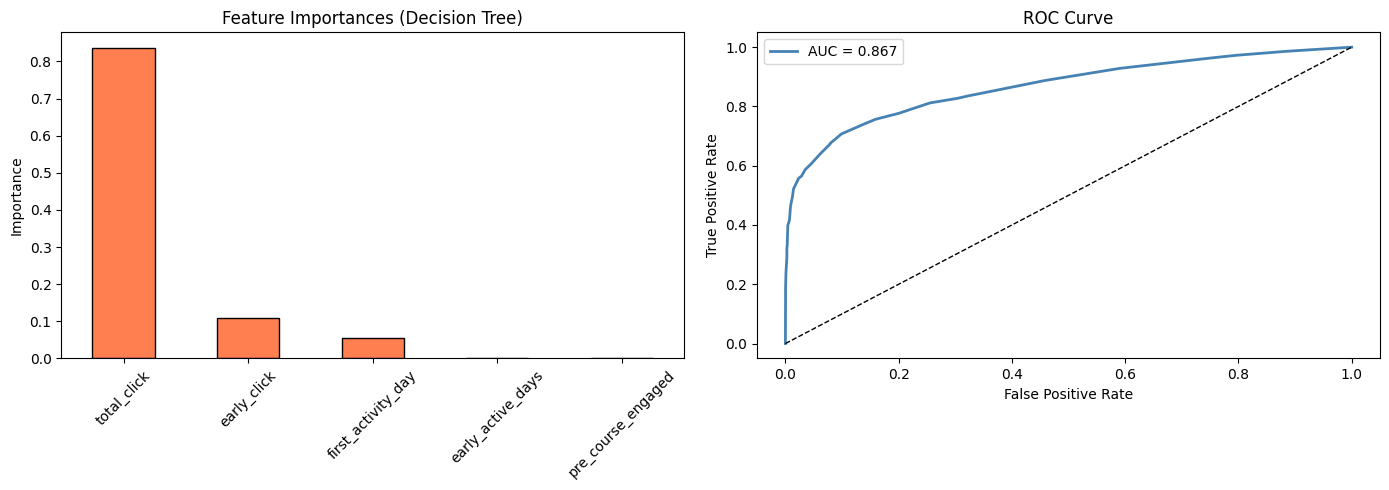

✅ Saved: 03_model_evaluation.png


In [22]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importance.plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Feature Importances (Decision Tree)")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis="x", rotation=45)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 03_model_evaluation.png")

In [23]:
def explain_tree_decision(model, input_df, feature_names):
    node_indicators = model.decision_path(input_df)
    feature   = model.tree_.feature
    threshold = model.tree_.threshold
    explanation = []
    for node_id in node_indicators.indices:
        if feature[node_id] != -2:  # -2 == leaf node
            fname  = feature_names[feature[node_id]]
            thresh = threshold[node_id]
            val    = input_df.iloc[0][fname]
            direction = "<=" if val <= thresh else ">"
            explanation.append(
                f"{fname.replace('_', ' ').title()} {direction} {int(thresh)}"
            )
    return explanation

# Demonstrate on first test sample
sample_df = X_test.iloc[[0]]
explanation = explain_tree_decision(model, sample_df, feature_cols)

print("Decision path for sample student:")
for step in explanation:
    print(f"  → {step}")
print(f"  Prediction: at_risk={model.predict(sample_df)[0]}  (prob={model.predict_proba(sample_df)[0][1]:.3f})")

Decision path for sample student:
  → Total Click > 376
  → Total Click > 1165
  → Total Click <= 3168
  → Early Click > 284
  → Total Click > 2123
  Prediction: at_risk=0  (prob=0.371)


## 💡 Step 10 — Recommendation Engine

In [24]:
import yaml

with open(CONFIG_PATH / "config.yaml") as f:
    THRESHOLDS = yaml.safe_load(f)

print("Loaded config:")
print(THRESHOLDS)

Loaded config:
{'risk_levels': {'high': 0.7, 'medium': 0.4}, 'early_engagement': {'min_early_click': 50}}


In [25]:
def generate_recommendations(risk_probability, student_input):
    observations = []
    actions      = []

    if student_input["early_active_days"] == 0:
        observations.append("No engagement in early course period")
        actions.append("Start with introductory materials immediately.")

    if student_input["early_click"] < THRESHOLDS["early_engagement"]["min_early_click"]:
        observations.append("Low early interaction with course content")
        actions.append("Watch intro videos and explore course structure")

    if student_input["first_activity_day"] > 0:
        observations.append("Late course start compared to peers")
        actions.append("Follow a structured 7-day recovery plan")

    if risk_probability >= THRESHOLDS["risk_levels"]["high"]:
        actions.append("Schedule academic support or mentoring session.")

    return observations, actions

## 🔄 Step 11 — End-to-End Prediction Pipeline

In [26]:
def predict_and_recommend(student_dict, model, feature_cols):
    required = ["total_click", "early_click", "early_active_days",
                "first_activity_day", "pre_course_engaged"]
    missing = [k for k in required if k not in student_dict]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")

    input_df = pd.DataFrame([student_dict])
    input_df["first_activity_day"] = input_df["first_activity_day"].fillna(999)
    input_df = input_df[feature_cols].fillna(0)

    risk_probability = model.predict_proba(input_df)[0][1]

    if risk_probability >= THRESHOLDS["risk_levels"]["high"]:
        risk_level = "High"
    elif risk_probability >= THRESHOLDS["risk_levels"]["medium"]:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    observations, actions = generate_recommendations(risk_probability, student_dict)
    tree_explanation      = explain_tree_decision(model, input_df, feature_cols)

    return {
        "risk_probability" : round(float(risk_probability), 3),
        "risk_level"       : risk_level,
        "observations"     : observations,
        "recommendations"  : actions,
        "model_explanation": tree_explanation,
    }

In [27]:
# ── High-risk student example ─────────────────────────────────────────────────
sample_high_risk = {
    "total_click"       : 80,
    "early_click"       : 0,
    "early_active_days" : 0,
    "first_activity_day": 15,
    "pre_course_engaged": 0,
}

result = predict_and_recommend(sample_high_risk, model, feature_cols)

print("=" * 55)
print(f"  Risk Level      : {result['risk_level']}")
print(f"  Risk Probability: {result['risk_probability']}")
print("\n  Observations:")
for obs in result["observations"]:
    print(f"    ⚠️  {obs}")
print("\n  Recommendations:")
for act in result["recommendations"]:
    print(f"    ✅  {act}")
print("\n  Model Decision Path:")
for step in result["model_explanation"]:
    print(f"    →  {step}")

  Risk Level      : Medium
  Risk Probability: 0.618

  Observations:
    ⚠️  No engagement in early course period
    ⚠️  Low early interaction with course content
    ⚠️  Late course start compared to peers

  Recommendations:
    ✅  Start with introductory materials immediately.
    ✅  Watch intro videos and explore course structure
    ✅  Follow a structured 7-day recovery plan

  Model Decision Path:
    →  Total Click <= 376
    →  Total Click <= 138
    →  Total Click > 59
    →  First Activity Day > 12
    →  First Activity Day <= 16


In [28]:
# ── Low-risk student example ──────────────────────────────────────────────────
sample_low_risk = {
    "total_click"       : 800,
    "early_click"       : 120,
    "early_active_days" : 8,
    "first_activity_day": -5,
    "pre_course_engaged": 1,
}

result2 = predict_and_recommend(sample_low_risk, model, feature_cols)
print(f"Risk Level      : {result2['risk_level']}")
print(f"Risk Probability: {result2['risk_probability']}")

Risk Level      : Medium
Risk Probability: 0.455


## 💾 Step 12 — Save Trained Model & Output Files

In [29]:
# Save retrained model
model_out_path = OUTPUT_DIR / "finalized_model.joblib"
joblib.dump(model, model_out_path)
print(f"✅ Model saved       : {model_out_path}")

# Save metrics
metrics_df = pd.DataFrame({"metric": ["accuracy", "roc_auc"], "value": [acc, roc_auc]})
metrics_df.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
print("✅ Metrics saved     : model_metrics.csv")

# Save feature importances
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", header=["importance"])
print("✅ Importances saved : feature_importance.csv")

print("\nAll output files so far:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"   {f.name}")

✅ Model saved       : /content/outputs/finalized_model.joblib
✅ Metrics saved     : model_metrics.csv
✅ Importances saved : feature_importance.csv

All output files so far:
   01_engagement_overview.png
   02_temporal_signals.png
   03_model_evaluation.png
   feature_importance.csv
   finalized_model.joblib
   model_metrics.csv


## 📋 Step 13 — Batch Predictions on Test Set

In [30]:
test_results = X_test.copy()
test_results["true_at_risk"]      = y_test.values
test_results["predicted_at_risk"] = y_pred
test_results["risk_probability"]  = y_proba

def map_risk_level(prob):
    if prob >= THRESHOLDS["risk_levels"]["high"]:
        return "High"
    elif prob >= THRESHOLDS["risk_levels"]["medium"]:
        return "Medium"
    return "Low"

test_results["risk_level"] = test_results["risk_probability"].apply(map_risk_level)
test_results.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print(f"✅ Test predictions saved ({len(test_results)} rows)")
display(test_results.head(10))

✅ Test predictions saved (6519 rows)


,total_click,early_click,early_active_days,first_activity_day,pre_course_engaged,true_at_risk,predicted_at_risk,risk_probability,risk_level
23252,2948.0,334.0,6.0,-14.0,1.0,0,0,0.371429,Low
30849,39.0,9.0,3.0,-13.0,1.0,1,1,0.990244,High
21169,678.0,19.0,4.0,-11.0,1.0,0,0,0.421101,Medium
30521,940.0,50.0,3.0,-10.0,1.0,0,0,0.270525,Low
29539,4035.0,688.0,11.0,-15.0,1.0,0,0,0.335664,Low
18908,5280.0,394.0,11.0,-25.0,1.0,0,0,0.108434,Low
29351,462.0,147.0,7.0,-12.0,1.0,1,1,0.907975,High
11315,5.0,0.0,0.0,-17.0,1.0,1,1,0.998839,High
31609,5.0,3.0,1.0,4.0,0.0,1,1,0.998839,High
25510,4628.0,242.0,13.0,-15.0,1.0,0,0,0.108434,Low


Predicted Risk Level Distribution:


,count
risk_level,
Low,2940
High,2224
Medium,1355


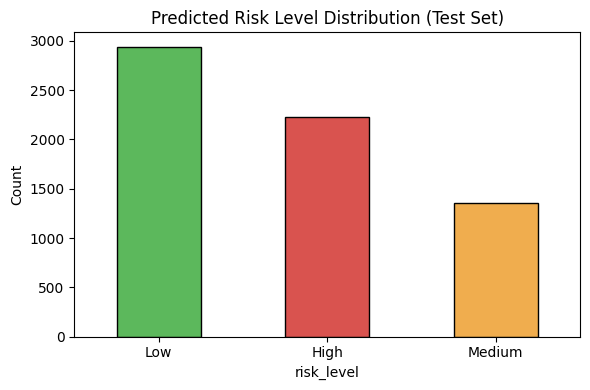

✅ Saved: 04_risk_distribution.png


In [31]:
risk_summary = test_results["risk_level"].value_counts()
print("Predicted Risk Level Distribution:")
display(risk_summary.to_frame("count"))

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"High": "#d9534f", "Medium": "#f0ad4e", "Low": "#5cb85c"}
risk_summary.plot(
    kind="bar", ax=ax,
    color=[colors.get(r, "gray") for r in risk_summary.index],
    edgecolor="black"
)
ax.set_title("Predicted Risk Level Distribution (Test Set)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_risk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: 04_risk_distribution.png")

## 📦 Step 14 — Zip All Outputs & Download

All charts, the trained model, metrics CSVs, and predictions are bundled
into a single ZIP file which is automatically downloaded.

In [32]:
import zipfile

zip_output_path = "/content/student_engagement_outputs.zip"

with zipfile.ZipFile(zip_output_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(OUTPUT_DIR.iterdir()):
        zf.write(f, arcname=f.name)
        print(f"   Added: {f.name}")

print(f"\n✅ Archive created: {zip_output_path}")

from google.colab import files
files.download(zip_output_path)

   Added: 01_engagement_overview.png
   Added: 02_temporal_signals.png
   Added: 03_model_evaluation.png
   Added: 04_risk_distribution.png
   Added: feature_importance.csv
   Added: finalized_model.joblib
   Added: model_metrics.csv
   Added: test_predictions.csv

✅ Archive created: /content/student_engagement_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>